<a href="https://colab.research.google.com/github/tdineth/Image-Processing-CO5430-4th-sem/blob/main/lab04/E_23_076_Lab_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [14]:
img_path="/content/drive/MyDrive/Image Processing - CO5430 - 4th sem/lab4/Efac.jpg"

### Task 1 — Threshold for Foreground/Background Separation


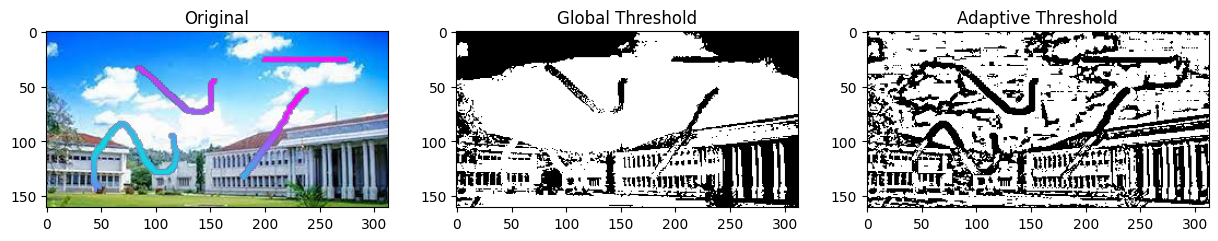

In [15]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Global Threshold
_, global_thr = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

# Adaptive Threshold
adaptive_thr = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(img)
plt.title("Original")

plt.subplot(132)
plt.imshow(global_thr,cmap='gray')
plt.title("Global Threshold")

plt.subplot(133)
plt.imshow(adaptive_thr,cmap='gray')
plt.title("Adaptive Threshold")

plt.show()

**1. Which regions are consistently detected by both methods?**

Both Global Thresholding and Adaptive Thresholding successfully detect the scribbles, building boundaries, columns and some roof edges because these regions have strong intensity differences from their surroundings.

**2. Are there areas where one method succeeds while the other misses information?**

Yes. The Adaptive Threshold preserves much more local detail, especially around the clouds, windows, roof edges and textured regions. In contrast, the Global Threshold loses many of these details and merges large bright areas, such as the sky and clouds, into one region.

**3. Look carefully at the sky, buildings, shadows, and grass. Do all regions respond similarly to thresholding?**

No.

* The sky becomes mostly white in the global threshold because it is bright.
* The buildings are partially detected but lose some fine details under global thresholding.
* Shadowed regions are not segmented consistently by the global method.
* The grass contains many intensity variations and appears fragmented, especially in the adaptive threshold output.

Different regions respond differently because they have different brightness and texture characteristics.


**Reflection**

**Based on your observations, what image characteristics might make a single threshold value insufficient?**


A single threshold value is insufficient because the image contains uneven illumination, shadows, textured grass, bright clouds and dark building regions. Since pixel intensities vary across the scene, one threshold cannot correctly separate foreground and background everywhere. Adaptive thresholding performs better because it computes thresholds locally.

**More to Think**

**Is segmentation purely by intensity reliable outdoors?**

No. Outdoor images contain changing lighting conditions, shadows, reflections, clouds, and textured surfaces, causing the same object to have different intensity values and different objects to have similar intensities. Therefore, segmentation based only on intensity is generally not reliable for outdoor scenes.


### Task 2 — K-Means Pixel Clustering

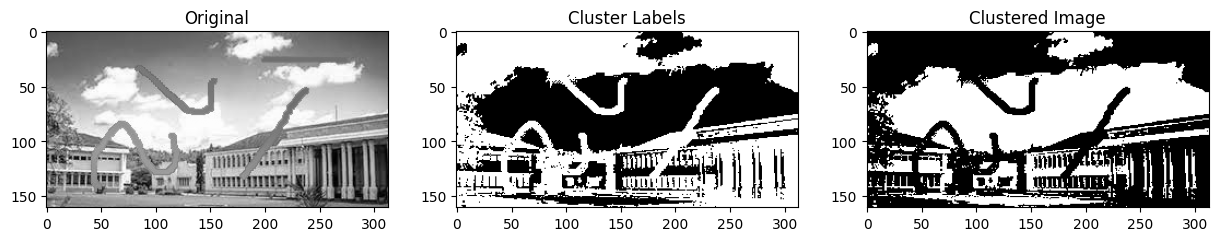

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Reshape image into a vector
Z = gray.reshape((-1,1))
Z = np.float32(Z)

# Define stopping criteria
criteria = (cv2.TERM_CRITERIA_EPS +
            cv2.TERM_CRITERIA_MAX_ITER,
            10,
            1.0)

# Number of clusters
K = 2

# Apply K-Means
ret, label, center = cv2.kmeans(
    Z,
    K,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

# Convert centers back to uint8
center = np.uint8(center)

# Reconstruct image
result = center[label.flatten()]
result = result.reshape(gray.shape)

# Display
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(gray, cmap='gray')
plt.title("Original")

plt.subplot(132)
plt.imshow(label.reshape(gray.shape), cmap='gray')
plt.title("Cluster Labels")

plt.subplot(133)
plt.imshow(result, cmap='gray')
plt.title("Clustered Image")

plt.show()

**1. Which image regions are grouped together?**

The bright regions, such as the sky, clouds and upper parts of the image, are grouped into one cluster.The darker regions, including the building, columns, grass, shadows and scribbles, are grouped into the other cluster based on their grayscale intensity values.

**2. Are the scribbled regions assigned to a different cluster from the surrounding scene?**

The scribbled regions are mostly assigned to a different cluster from the bright sky, making them stand out clearly. However, some scribbles overlap with darker parts of the building and are grouped together with those regions because they have similar intensity values.

**3. Do visually different objects sometimes appear in the same cluster?**

Yes. In the clustered image, grass, building walls, windows, and some scribbles appear in the same cluster because they have similar grayscale intensities, even though they are completely different objects.


**Reflection**

**What information is K-Means using when assigning pixels to clusters?**

K-Means uses only the grayscale intensity value of each pixel to assign clusters. It groups pixels with similar brightness levels and does not consider their position, shape, texture or semantic meaning in the image.

**More to Think When can two different objects fall into one cluster?**

Two different objects can fall into the same cluster when they have similar intensity values. For example, the building walls and dark scribbles or the clouds and bright roof surfaces may be placed in the same cluster even though they represent different objects because K-Means relies only on pixel intensity.

### Task 3 — Edge Map for Structure Protection


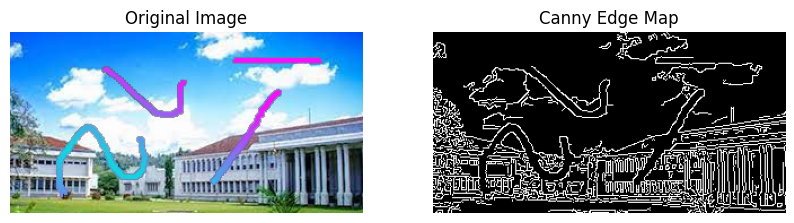

In [18]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Apply Canny edge detector
edges = cv2.Canny(gray, 80, 160)

# Display results
plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Map")
plt.axis("off")

plt.show()

**1. Identify edges belonging to buildings, roofs, windows, and other scene structures.**

The edge map clearly detects the roof boundary, building outline, columns, windows and the edges of the trees. These structures appear as continuous white lines because they have strong intensity changes with the surrounding regions.

**2. Identify edges created by the scribbles.**

The colored scribbles are clearly detected as curved white edges in the edge map. Their outlines are visible across the sky and building areas because they have high contrast with the background image.

**3. Compare the thickness, continuity, and location of different edge types.**

- The detected edges are thin and approximately one pixel wide.
- Building edges are mostly straight and continuous, especially along the roof and columns.
- Scribble edges are curved and irregular but are also continuous over most of their length.
- Some edges around trees and textured regions appear fragmented due to complex image textures.

**Reflection**

**If important structural edges are removed during restoration, how might the final image be affected?**

If important structural edges are removed during restoration, the building boundaries, roof lines and columns may become blurred or distorted, making the restored image look unnatural. Preserving these edges helps maintain the original shape and structure of objects in the scene.

**More to Think**

**Do scribbles always have different edge patterns than architecture?**

No. Although the scribbles in this image form smooth curved edges while the building mostly contains straight geometric edges, some scribbles overlap with architectural features and produce edges with similar strength. Therefore, edge information alone is not always sufficient to distinguish scribbles from scene structures.

### Task 4 — Create a Damage Mask

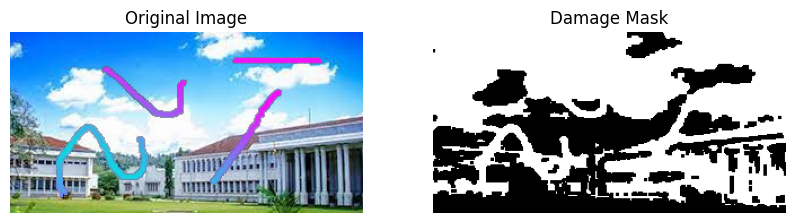

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Blue scribble range
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([140, 255, 255])

# Magenta/Purple scribble range
lower_magenta = np.array([140, 50, 50])
upper_magenta = np.array([179, 255, 255])

# Create masks
mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)
mask_magenta = cv2.inRange(hsv, lower_magenta, upper_magenta)

# Combine masks
mask = cv2.bitwise_or(mask_blue, mask_magenta)

# Fill small gaps
kernel = np.ones((3,3), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Display
plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Damage Mask")
plt.axis("off")

plt.show()

**1. Does the mask cover all damaged pixels?**

The mask covers most of the scribbled regions, especially the large curved scribbles across the sky and building. However, it also includes some surrounding areas that are not actually damaged.

**2. Are any valid image regions mistakenly included?**

Yes. The mask includes parts of the sky, clouds, roof, and some building regions that are not scribbles. This indicates that the segmentation is not perfectly selective and has included some valid image pixels.

**3. Are there gaps inside the marked scribbles?**

The scribbled regions are mostly continuous, with very few visible gaps. The mask successfully captures most of the damaged pixels, although small missing sections may still exist near the edges of some scribbles.

**Reflection**

**How might under-segmentation or over-segmentation affect restoration quality?**

- Under-segmentation would leave some scribbled pixels outside the mask, causing parts of the unwanted markings to remain after restoration.
- Over-segmentation, which is visible in this mask, includes undamaged regions such as parts of the sky and building. During inpainting, these valid image regions would also be replaced, potentially producing unrealistic textures and loss of important details.

#### Task 5 — Restore Damaged Regions Using Inpainting

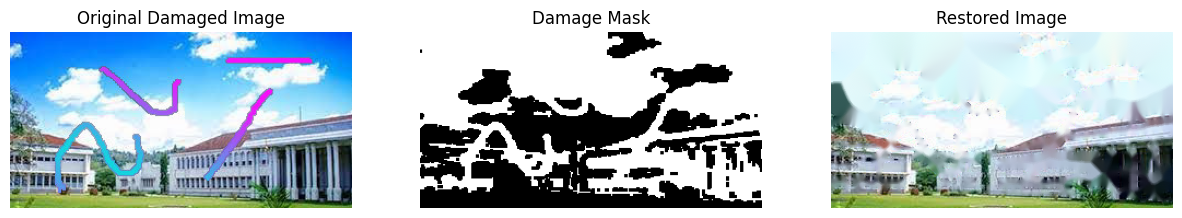

In [24]:
import cv2
import matplotlib.pyplot as plt

# Read original image
img = cv2.imread(img_path)

# 'mask' is the binary mask obtained in Task 4
# White (255) = damaged region
# Black (0) = undamaged region

# Apply inpainting
restored = cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)

# Convert for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
restored_rgb = cv2.cvtColor(restored, cv2.COLOR_BGR2RGB)

# Display results
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(img_rgb)
plt.title("Original Damaged Image")
plt.axis("off")

plt.subplot(132)
plt.imshow(mask, cmap="gray")
plt.title("Damage Mask")
plt.axis("off")

plt.subplot(133)
plt.imshow(restored_rgb)
plt.title("Restored Image")
plt.axis("off")

plt.show()

**1. Compare the original damaged image, mask, and restored image.**

The restored image successfully removes most of the colored scribbles. However, because the damage mask covers a large portion of the image, the inpainting algorithm also reconstructs some undamaged regions, causing noticeable changes to the original scene.

**2. Look closely at the building boundaries.**

The building boundaries are not fully preserved. Some columns and roof edges appear blurred and distorted, indicating that important structural information was removed during restoration.

**3. Look closely at the sky regions.**

The sky is restored smoothly in some areas, but several regions contain unnatural patches and repeated cloud-like textures. This occurs because the algorithm estimates missing pixels using neighboring information.

**4. Look closely at the grass textures.**

The grass texture is partially blurred and less detailed than the original image. Fine texture patterns are not reconstructed accurately, giving the restored region a smoother appearance.

**Reflection**

**Where does the restoration appear natural, and where does it appear less convincing?**

The restoration appears relatively natural in large smooth regions such as parts of the sky, where surrounding pixels have similar colors. It appears less convincing around the building, clouds, and grass, where complex structures and textures have been blurred or incorrectly reconstructed.

**What characteristics of the surrounding region might influence the quality of the reconstructed content?**

The quality of reconstruction depends on the surrounding colors, textures, and structural continuity. Uniform regions are restored more accurately, while regions containing complex textures, edges, and architectural details are more difficult to reconstruct and may produce visible artifacts.

**More to Think**

**How does inpainting hallucinate incorrect content on complex textures?**

The inpainting algorithm fills missing regions by copying and interpolating information from neighboring pixels. When the missing region contains complex textures or detailed structures, there may not be enough surrounding information to reconstruct the original content correctly. As a result, the algorithm generates blurred patterns, repeated textures or unrealistic structures, which can be seen in the restored image.

**Final Reflection**

**1. How did thresholding and clustering contribute to identifying damaged regions?**

Thresholding separated pixels based on their intensity values, making high-contrast regions easier to identify. K-Means clustering grouped pixels with similar brightness into clusters, helping distinguish many of the scribbled regions from the background. Together, these methods provided useful information for creating the damage mask.

**2. Which segmentation approach appeared most useful for this image?**

Adaptive thresholding appeared to be the most useful because it handled variations in lighting and local image intensity better than global thresholding. It preserved more details around the buildings and scribbles, making segmentation more accurate.

**3. How did the quality of the mask influence the final restoration?**

The quality of the mask had a significant impact on the restoration result. Since the mask included some undamaged regions, the inpainting algorithm also modified those areas, causing blurring and distortion. A more accurate mask would produce a more realistic restoration.

**4. Why might preserving important structural edges improve restoration quality?**

Structural edges define the boundaries of objects such as buildings, roofs, and windows. Preserving these edges helps maintain the original shape and geometry of the scene, resulting in a more natural-looking restored image and reducing visible artifacts.

**5. What limitations did you observe in the restored image?**

The restored image shows several limitations:

- Some building details and roof edges are blurred.
- Clouds and sky contain unrealistic reconstructed patterns.
- Grass textures lose fine details and appear smoother than the original.
- Over-segmentation of the mask caused some valid image regions to be unnecessarily reconstructed, reducing the overall restoration quality.